In [1]:
from pathlib import Path
import sys
import time
import itertools

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn.functional as F

# Chargement du package TCA

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "src" / "trajectoryclusteringanalysis").exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver la racine du projet depuis {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis.tca import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Package chargé depuis : {src_path}")

Package chargé depuis : c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


In [2]:
# --- 1. Fixer les graines pour la reproductibilité ---
np.random.seed(42)
torch.manual_seed(42)

# --- 2. Configuration des dimensions ---
N = 400                    # Nombre de patients virtuels
T = 24                     # Durée du suivi (ex: 24 mois)
omega = 3                  # Taille de la fenêtre des phénotypes (\omega)
noms_events = ['Chimiothérapie IV', 'Chimiothérapie per os', 'Chirurgie', 'Radiothérapie']
V = len(noms_events)
R = 3                      # Nombre de phénotypes distincts à injecter

# --- 3. Définition stricte des Phénotypes (Vérité Terrain) ---
# Shape : (R, V, omega)
Ph_true = torch.zeros((R, V, omega))
# Phénotype 0 : Chirurgie immédiate (Mois 0)
Ph_true[0, noms_events.index('Chirurgie'), 0] = 1.0
# Phénotype 1 : Chimiothérapie IV continue (Mois 0, 1, 2)
Ph_true[1, noms_events.index('Chimiothérapie IV'), :] = 1.0
# Phénotype 2 : Radiothérapie ciblée tardive (Mois 2)
Ph_true[2, noms_events.index('Radiothérapie'), 2] = 1.0

# --- 4. Génération des trajectoires au format long ---
rows = []
W_true = torch.zeros((N, R, T - omega + 1)) # Pour garder une trace des vraies activations

for i in range(N):
    patient_id = f"PATIENT_{i:03d}"
    
    # Choix d'un phénotype principal et d'un mois d'activation aléatoire
    r_main = np.random.randint(R)
    t_start_main = np.random.randint(T - omega + 1)
    W_true[i, r_main, t_start_main] = 1.0
    
    # Traduction du phénotype en lignes d'événements pour le DataFrame
    for v in range(V):
        for tau in range(omega):
            if Ph_true[r_main, v, tau] > 0:
                rows.append({
                    'ID_PATIENT': patient_id,
                    'Time': t_start_main + tau,
                    'Event': noms_events[v]
                })
                
    # Un patient sur deux reçoit un deuxième traitement (phénotype secondaire) à un autre moment
    if np.random.rand() > 0.5:
        r_sec = np.random.randint(R)
        t_start_sec = np.random.randint(T - omega + 1)
        if t_start_sec != t_start_main: # Éviter une superposition stricte
            W_true[i, r_sec, t_start_sec] = 0.8
            for v in range(V):
                for tau in range(omega):
                    if Ph_true[r_sec, v, tau] > 0:
                        rows.append({
                            'ID_PATIENT': patient_id,
                            'Time': t_start_sec + tau,
                            'Event': noms_events[v]
                        })

# Création du DataFrame de base
timed_event_structure = pd.DataFrame(rows)

# --- 5. Ajout d'un bruit de fond aléatoire (Données parasites) ---
# Simule 5% d'événements aléatoires hors parcours de soins structurés
nb_bruit = int(len(timed_event_structure) * 0.05)
bruit_data = {
    'ID_PATIENT': [f"PATIENT_{np.random.randint(N):03d}" for _ in range(nb_bruit)],
    'Time': [np.random.randint(T) for _ in range(nb_bruit)],
    'Event': [np.random.choice(noms_events) for _ in range(nb_bruit)]
}
timed_event_structure = pd.concat([timed_event_structure, pd.DataFrame(bruit_data)], ignore_index=True)

# Tri final pour avoir une structure propre
timed_event_structure = timed_event_structure.sort_values(by=['ID_PATIENT', 'Time']).reset_index(drop=True)

print(f"Jeu de données synthétique généré : {len(timed_event_structure)} événements enregistrés.")
display(timed_event_structure.head(10))

Jeu de données synthétique généré : 1054 événements enregistrés.


,ID_PATIENT,Time,Event
0,PATIENT_000,9,Radiothérapie
1,PATIENT_000,21,Radiothérapie
2,PATIENT_001,20,Chirurgie
3,PATIENT_002,12,Radiothérapie
4,PATIENT_003,3,Chirurgie
5,PATIENT_004,23,Radiothérapie
6,PATIENT_005,5,Chimiothérapie IV
7,PATIENT_005,6,Chimiothérapie IV
8,PATIENT_005,7,Chimiothérapie IV
9,PATIENT_006,0,Chirurgie


In [3]:
# Initialisation de l'analyseur avec le nouveau jeu de données simulé
tca_synth = TCA(
    data=timed_event_structure, 
    index_col='ID_PATIENT',
    time_col='Time',
    event_col='Event',
    mode='multidimensional'
)

# Utilisation de la méthode de ton package pour créer le tenseur à partir du DataFrame
tca_synth.analyzer.transform_time_event_structure_to_tensor()
X_tensor_generated = tca_synth.analyzer.get_tensor()

print(f"Shape du tenseur calculé par l'analyseur : {X_tensor_generated.shape}")
# Devrait être proche de (400, 4, 24) ou ajusté selon la durée maximale observée

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (1054, 3)
state coding:
                    label  label encoded
0      Chimiothérapie IV              0
1  Chimiothérapie per os              1
2              Chirurgie              2
3          Radiothérapie              3
Shape du tenseur calculé par l'analyseur : torch.Size([400, 4, 24])


In [ ]:
# Entraînement sur le tenseur généré automatiquement
tca_synth.analyzer.fit_swotted_decomposition(
    X_tensor_generated,
    rank=R,
    time_window_length=omega,
    reg_term_ns=0.01,
    reg_term_s=0.01,
    metric='Bernoulli',
    learning_rate=1e-4,
    n_epochs=600,
    fit_metric_every_n_epochs=10,
    fit_metric_eval_max_patients=64,
    num_workers=0,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-4,
    early_stopping_monitor='fit_metric'
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelChec


 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (27) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Decomposed into 400 pathways with rank 3 and time window length 3
Success rate for the entire dataset: 0.4946


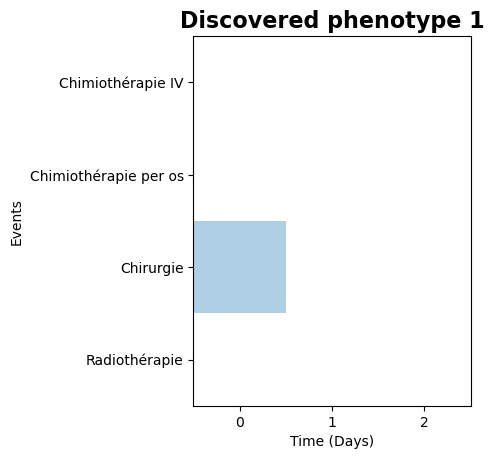

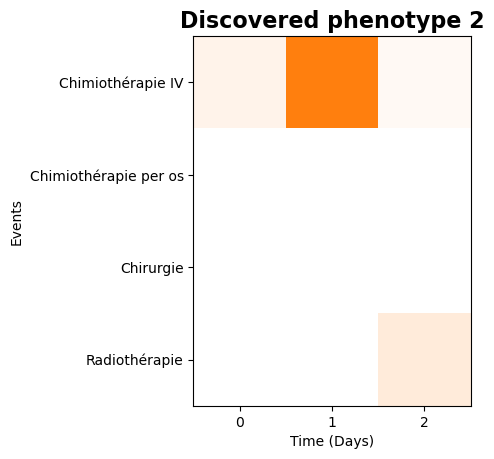

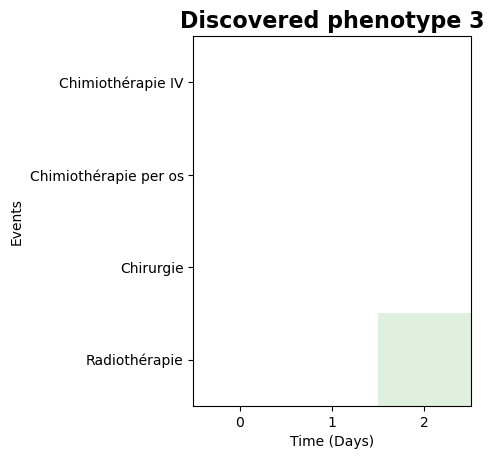

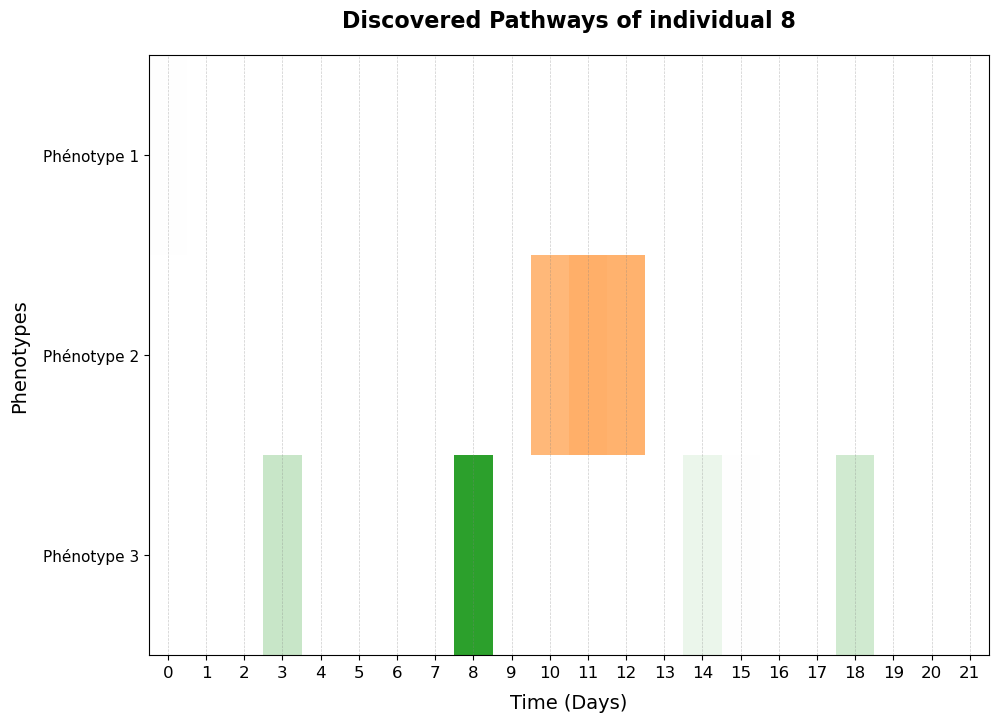

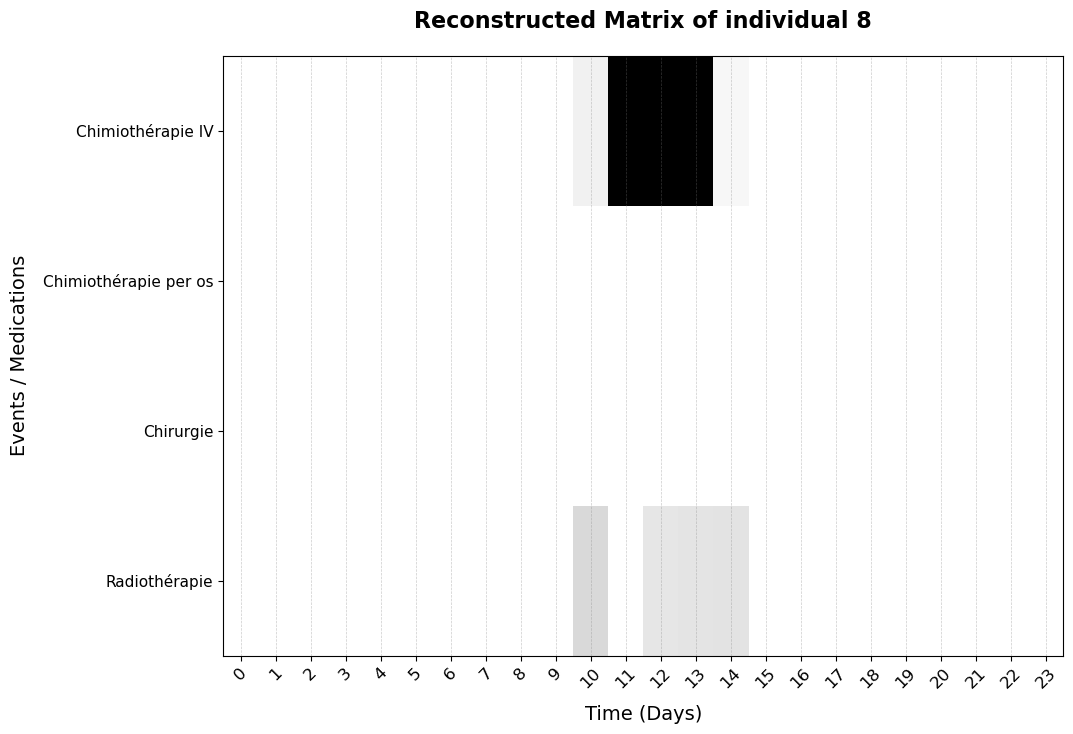

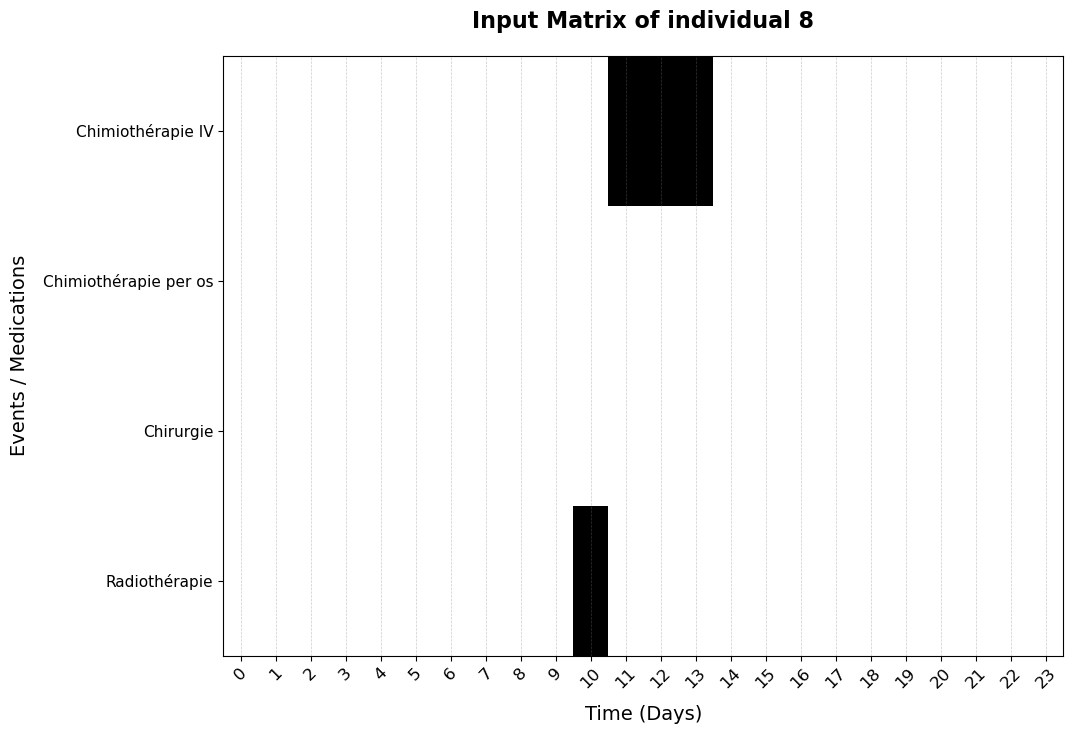

In [ ]:
tca_synth.analyzer.get_decomposition_results(
        labels=tca_synth.label_to_encoded,
        id=8,
        time_unit="Days"
    )

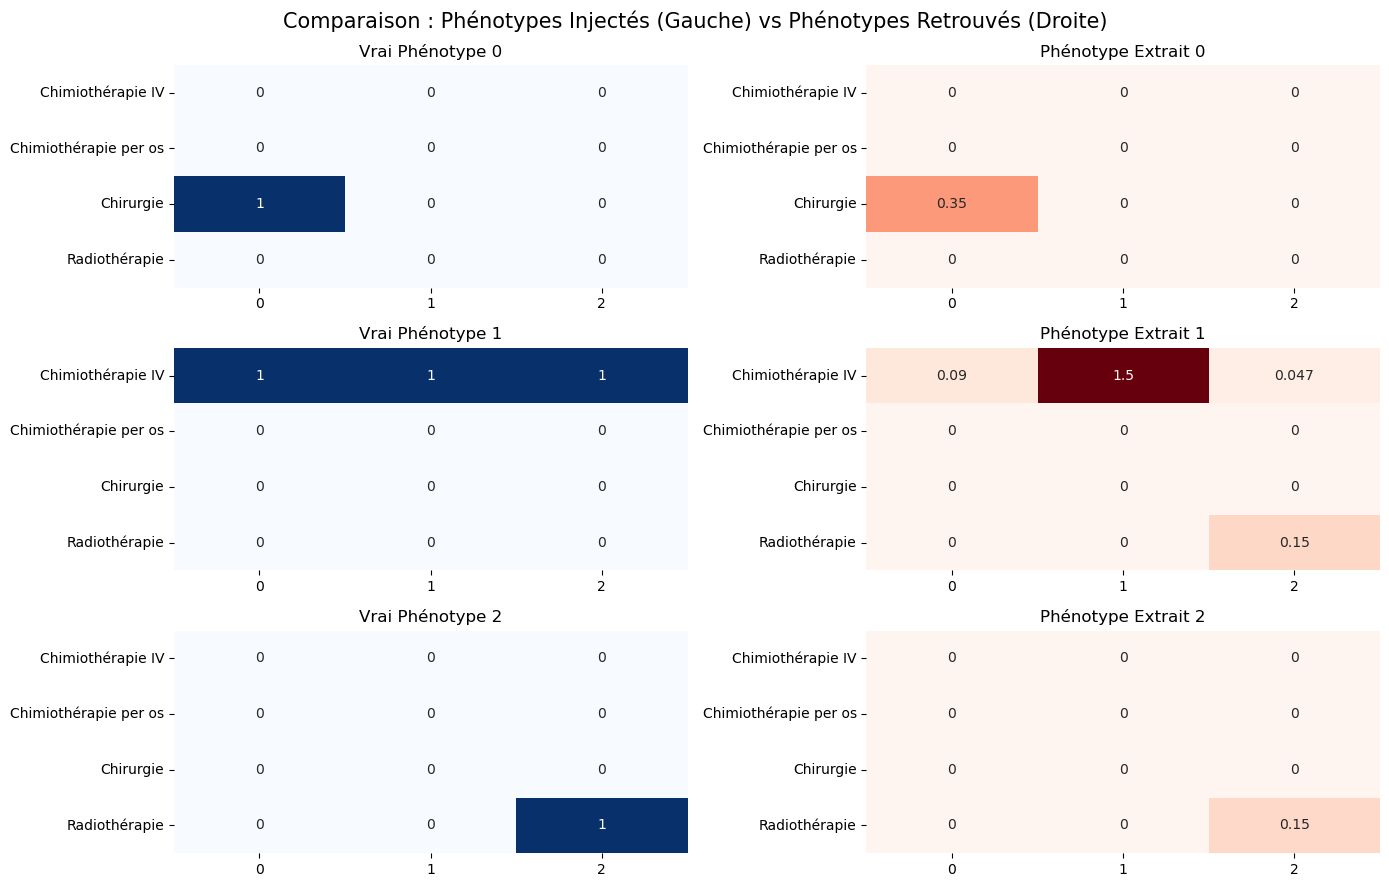

In [ ]:
# Récupération des phénotypes extraits
Ph_pred = tca_synth.analyzer.model.Ph.detach().cpu()

fig, axes = plt.subplots(R, 2, figsize=(14, R * 3))
fig.suptitle("Comparaison : Phénotypes Injectés (Gauche) vs Phénotypes Retrouvés (Droite)", fontsize=15)

for r in range(R):
    # Heatmap des vrais phénotypes
    sns.heatmap(Ph_true[r].numpy(), ax=axes[r, 0], cmap='Blues', vmin=0, vmax=1, annot=True, cbar=False)
    axes[r, 0].set_title(f"Vrai Phénotype {r}")
    axes[r, 0].set_yticklabels(noms_events, rotation=0)
    
    # Heatmap des phénotypes extraits
    # Rappel : l'ordre des phénotypes (0, 1, 2) peut être inversé/permuté à la sortie
    sns.heatmap(Ph_pred[r].numpy(), ax=axes[r, 1], cmap='Reds', vmin=0, vmax=1, annot=True, cbar=False)
    axes[r, 1].set_title(f"Phénotype Extrait {r}")
    axes[r, 1].set_yticklabels(noms_events, rotation=0)

plt.tight_layout()
plt.show()